In [3]:
import torch
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [4]:

file_path = "/kaggle/input/datasets/deepanshu0619/tweets/Tweets (1).csv"

df = pd.read_csv(file_path)

df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [5]:

texts = df['selected_text'].astype(str).tolist()

labels_raw = df['sentiment'].tolist()

label_map = {label: idx for idx, label in enumerate(sorted(set(labels_raw)))}
labels = [label_map[label] for label in labels_raw]

print("Label Mapping:", label_map)

Label Mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [6]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
class SimpleDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

dataset = SimpleDataset(encodings, labels)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(label_map),
    output_attentions=True
)

model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
model.train()

for epoch in range(2):
    print(f"\nEpoch {epoch+1}")
    
    total_loss = 0
    
    loop = tqdm(loader, leave=True)
    
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        optimizer.zero_grad()
        
        outputs = model(**batch)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(loader)
    print(f"Average Loss: {avg_loss:.4f}")


Epoch 1


100%|██████████| 3436/3436 [10:13<00:00,  5.60it/s, loss=0.35]   


Average Loss: 0.3160

Epoch 2


100%|██████████| 3436/3436 [10:14<00:00,  5.59it/s, loss=0.00404]

Average Loss: 0.1992


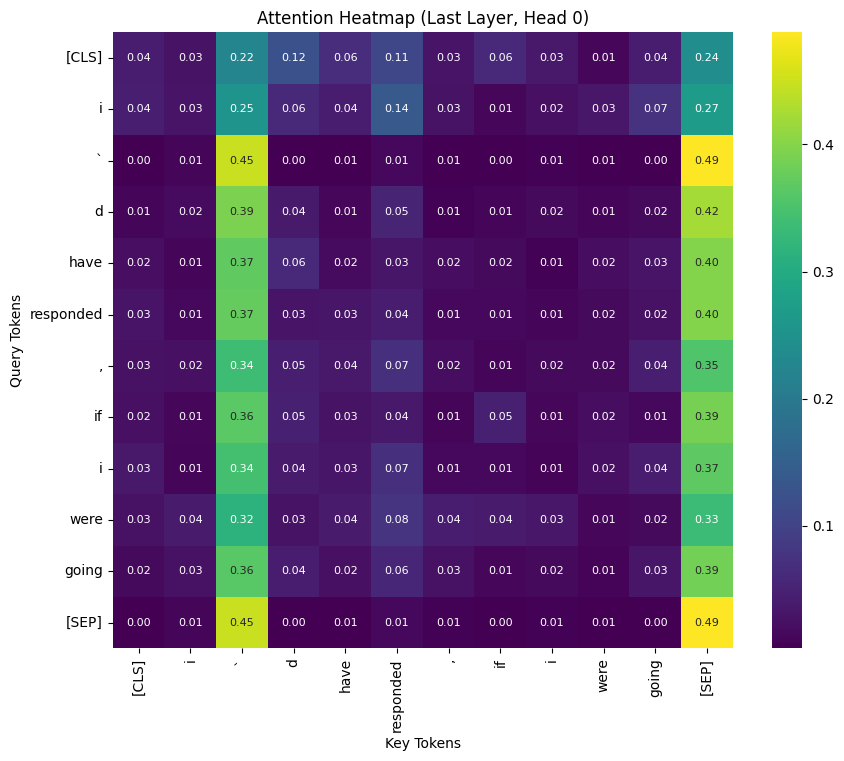

In [13]:
model.eval()

sample_text = texts[0]

inputs = tokenizer(sample_text, return_tensors="pt").to(device)
outputs = model(**inputs)

attentions = outputs.attentions

tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

attention = attentions[-1][0][0].detach().cpu().numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap="viridis",annot=True,        # ✅ show values
    fmt=".2f",annot_kws={"size": 8})
plt.title("Attention Heatmap (Last Layer, Head 0)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.xticks(rotation=90)
plt.show()

In [14]:
from sklearn.metrics import accuracy_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))

Accuracy: 0.9719806411702631


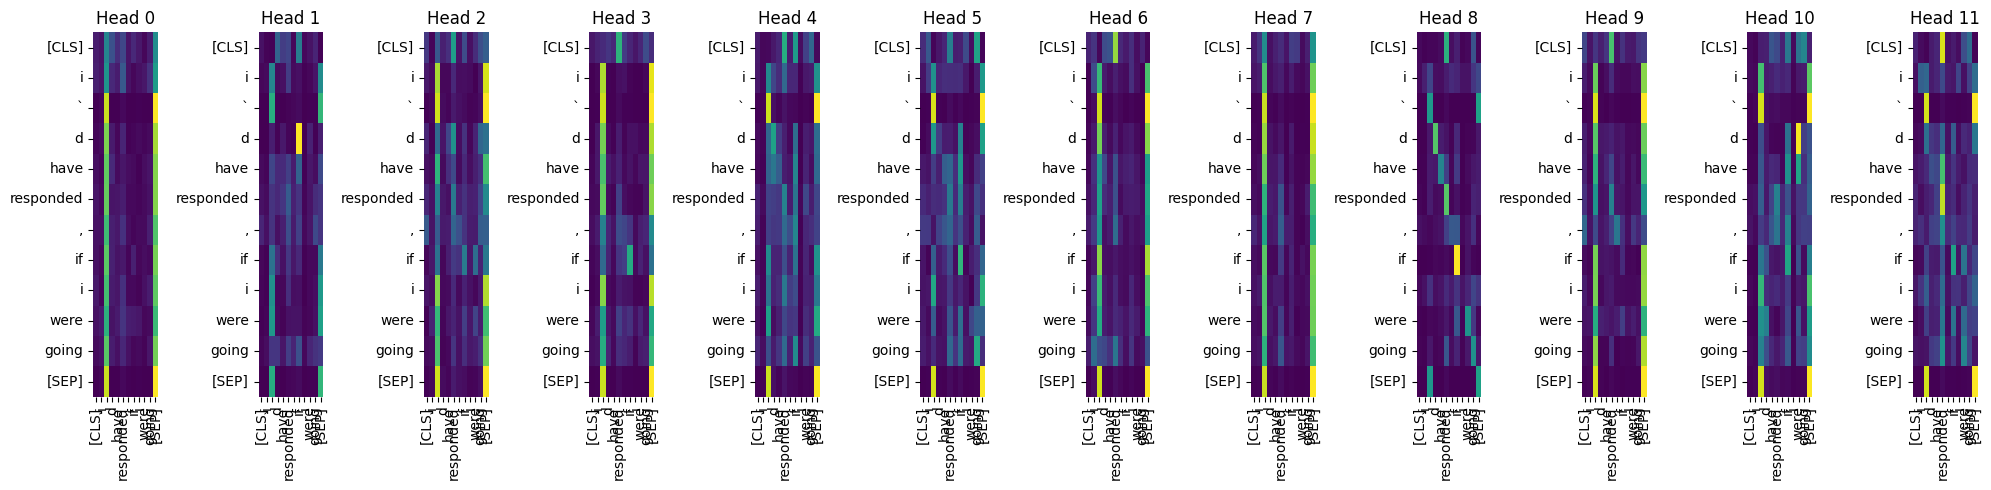

In [15]:
num_heads = attentions[-1].shape[1]

fig, axes = plt.subplots(1, num_heads, figsize=(20, 5))

for i in range(num_heads):
    ax = axes[i]
    head_attention = attentions[-1][0][i].detach().cpu().numpy()
    
    sns.heatmap(head_attention,
                xticklabels=tokens,
                yticklabels=tokens,
                cmap="viridis",
                ax=ax,
                cbar=False)
    
    ax.set_title(f"Head {i}")

plt.tight_layout()
plt.show()